In [2]:
#check the kernel
import sys
print(sys.executable)
print(sys.version)
print(sys.version_info)

sys.path.insert(0, '/home/fs01/dy327/venv/nbott/bott')

/home/fs01/dy327/miniconda/envs/bott6/bin/python
3.11.12 | packaged by conda-forge | (main, Apr 10 2025, 22:23:25) [GCC 13.3.0]
sys.version_info(major=3, minor=11, micro=12, releaselevel='final', serial=0)


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import glob, os, re
from PIL import Image
from bott.io import load_tif
import torch
from bott.problem import OptimizationProblem
from bott.utils import normalize_arr
from bott.reduction import get_domain_tiles

In [20]:
def load_pacbed(x):
    tag = f'./imgs/th{x[0]}_tx{x[1]}_ty{x[2]}.tif'
    return normalize_arr(load_tif(tag), 'standardize')#'zero_to_one') #np.asarray(Image.open(tag))

### back up functions

In [ ]:
import psutil

# Get virtual memory information
mem = psutil.virtual_memory()

# Print details
print(f"Total RAM: {mem.total / (1024**3):.2f} GB")
print(f"Available RAM: {mem.available / (1024**3):.2f} GB")
print(f"Used RAM: {mem.used / (1024**3):.2f} GB")
print(f"RAM Usage Percentage: {mem.percent}%")

Total RAM: 92.78 GB
Available RAM: 3.78 GB
Used RAM: 87.55 GB
RAM Usage Percentage: 95.9%


In [ ]:
img_dir = './imgs/'
img_list = glob.glob(os.path.join(img_dir, '*.tif'))

In [ ]:
len(img_list)

9457

In [7]:
def extract_params_from_filename(path):
    # Use regex to find numeric values after each keyword
    match = re.search(r'th(\d+)_tx(-?\d+)_ty(-?\d+)', path)
    if match:
        thickness = int(match.group(1))
        tiltx = int(match.group(2))
        tilty = int(match.group(3))
        #return torch.tensor([thickness, tiltx, tilty], dtype=torch.float)
        return [thickness, tiltx, tilty]
    else:
        raise ValueError(f"Could not parse path: {path}")

In [8]:
X_total = np.stack([extract_params_from_filename(p) for p in img_list])

In [9]:
X_total.shape

(9457, 3)

In [ ]:
# imgs = defaultdict(lambda: defaultdict(list))

# for th in range(50,1000,50):
#     for tx in range(0,10,1):
#         tag = f'./imgs/th{th}_tx{tx}_ty2.tif'
#         imgs[th][tx] = np.asarray(Image.open(tag))

In [ ]:
#mask conditions 
#get the subset of X using indices
# Define the range conditions
# condition_1 = (X_total[:, 0] >= 350) & (X_total[:, 0] <= 350)  # for variable 1
# condition_2 = (X_total[:, 1] >= 2) & (X_total[:, 1] <= 2)   # for variable 2
# condition_3 = (X_total[:, 2] >= 2) & (X_total[:, 2] <= 2)  # for variable 3

condition_1 =  (X_total[:, 0] == 350)  # for variable 1
condition_2 = (X_total[:, 1] == 2)   # for variable 2
condition_3 =  (X_total[:, 2] == 2)  # for variable 3

# Combine conditions (element-wise AND)
filtered_indices = condition_1 & condition_2 & condition_3

In [ ]:
np.where(filtered_indices)[0][0]

2001

In [ ]:
ground_truth_x = [350,2,2]
ground_truth_x_ind = [np.where(np.arange(50,1000,50)==ground_truth_x[0])[0][0],
                      np.where(np.arange(0,10,1)==ground_truth_x[1])[0][0],
                      np.where(np.arange(0,10,1)==ground_truth_x[2])[0][0]]
print(ground_truth_x_ind)

[6, 2, 2]


### back to the code

```python
for thickness in range(50,1000,50): #20
    for tilt_x in range(0,10,1):
        for tilt_y in range(0,10,1):

for thickness in range(25,1000,50): #20
    for tilt_x in range(-10,10,1):
        for tilt_y in range(-10,10,1):
```

TODOS

0. 350, 2, 2
1. 250, 2, 6
2. 720, 0, 0
3. crop to small angle

[6, 2, 2]


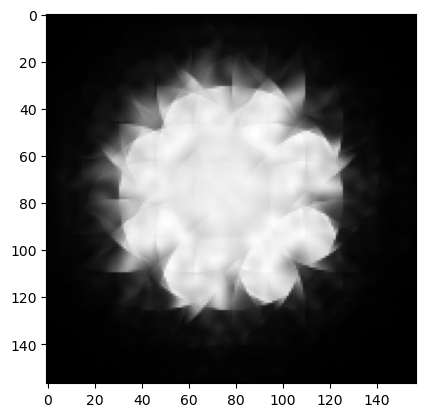

In [21]:
### set up variables
ground_truth_x = [350,2,2]
thickness_range = np.arange(50,1000,50) #19
tilt_x_range = np.arange(0,10,1) #10

ground_truth_x_ind = [np.where(thickness_range==ground_truth_x[0])[0][0],
                      np.where(tilt_x_range==ground_truth_x[1])[0][0],
                      np.where(tilt_x_range==ground_truth_x[2])[0][0]]
print(ground_truth_x_ind)

ground_truth = load_pacbed(ground_truth_x)
plt.figure()
plt.imshow(ground_truth,cmap='gray')

In [39]:
np.max(ground_truth)

1.8860362

In [ ]:
# sq_tile_width = 3

In [22]:
# OptimizationProblem would keep all the tensor on the specified device
problem = OptimizationProblem(ground_truth=torch.Tensor(ground_truth),
                              output_path='./output/', 
                              save_results=True, 
                            #   reduction_params={'reduction_type':'square', 
                            #                     'reduction_kwargs':{'num_tiles':sq_tile_width}},
                              reduction_params={'reduction_type':'domain', 
                                                'reduction_kwargs':{'radius':0.31}},
                              loss_params={'loss_type':'SSE', 'dp_pow': 1}, 
                              norm_arr=False,
                              dim=3,#3, 
                              bounds=[(50,1000), (0, 10), (0,10)],
                              noise_std=0,
                              dtype=torch.float32, 
                              device='cpu'
                              ) # "cpu" or "cuda" for physics simulation

loss_func = problem.loss_func
reduction_true = problem.reduction_true.to(torch.float32) #patch term
measurement_true = problem.measurement_true.to(torch.float32) #ground_truth
sf_tile = problem.scaling_factor
#print(sf_tile) #wrong scaling factor here

In [23]:
sf_tile

24649

### Domain tile plots

todo: reduction without sse

In [7]:
arr_tiles = np.zeros((19,10,5))
arr_pixel_sse = np.zeros((19,10))
arr_patch_sse = np.zeros((19,10))
arr_epsilon = np.zeros((19,10))

for ind_th, th in enumerate(thickness_range): #thickness #19
    for ind_tx, tx in enumerate(tilt_x_range): #tilt_x #10
        ## load image to compare with ground truth
        #temp_img = torch.Tensor(normalize_arr(load_pacbed([th,tx,2]),'zero_to_one')).to(torch.float32)
        temp_img = torch.Tensor(load_pacbed([th,tx,2])).to(torch.float32)
        
        temp_pixel_loss = (temp_img-measurement_true).pow(2).sum(dim=(0,1))
        arr_pixel_sse[ind_th,ind_tx] = temp_pixel_loss.numpy()

        temp_patch = problem.reduction_func(temp_img) #tensor of size [9]
        arr_tiles[ind_th,ind_tx,:] = temp_patch.numpy()

        temp_patch_loss = sf_tile* loss_func(y_simu=temp_patch,
                                        y_true=reduction_true,
                                        reduce=False) #working correctly for SSE
        arr_patch_sse[ind_th,ind_tx] = temp_patch_loss.numpy()

        epsilon = temp_pixel_loss - temp_patch_loss
        arr_epsilon[ind_th,ind_tx] = epsilon.numpy()

In [21]:
arr_tiles.shape

(19, 10, 5)

In [8]:
from matplotlib.colors import TwoSlopeNorm

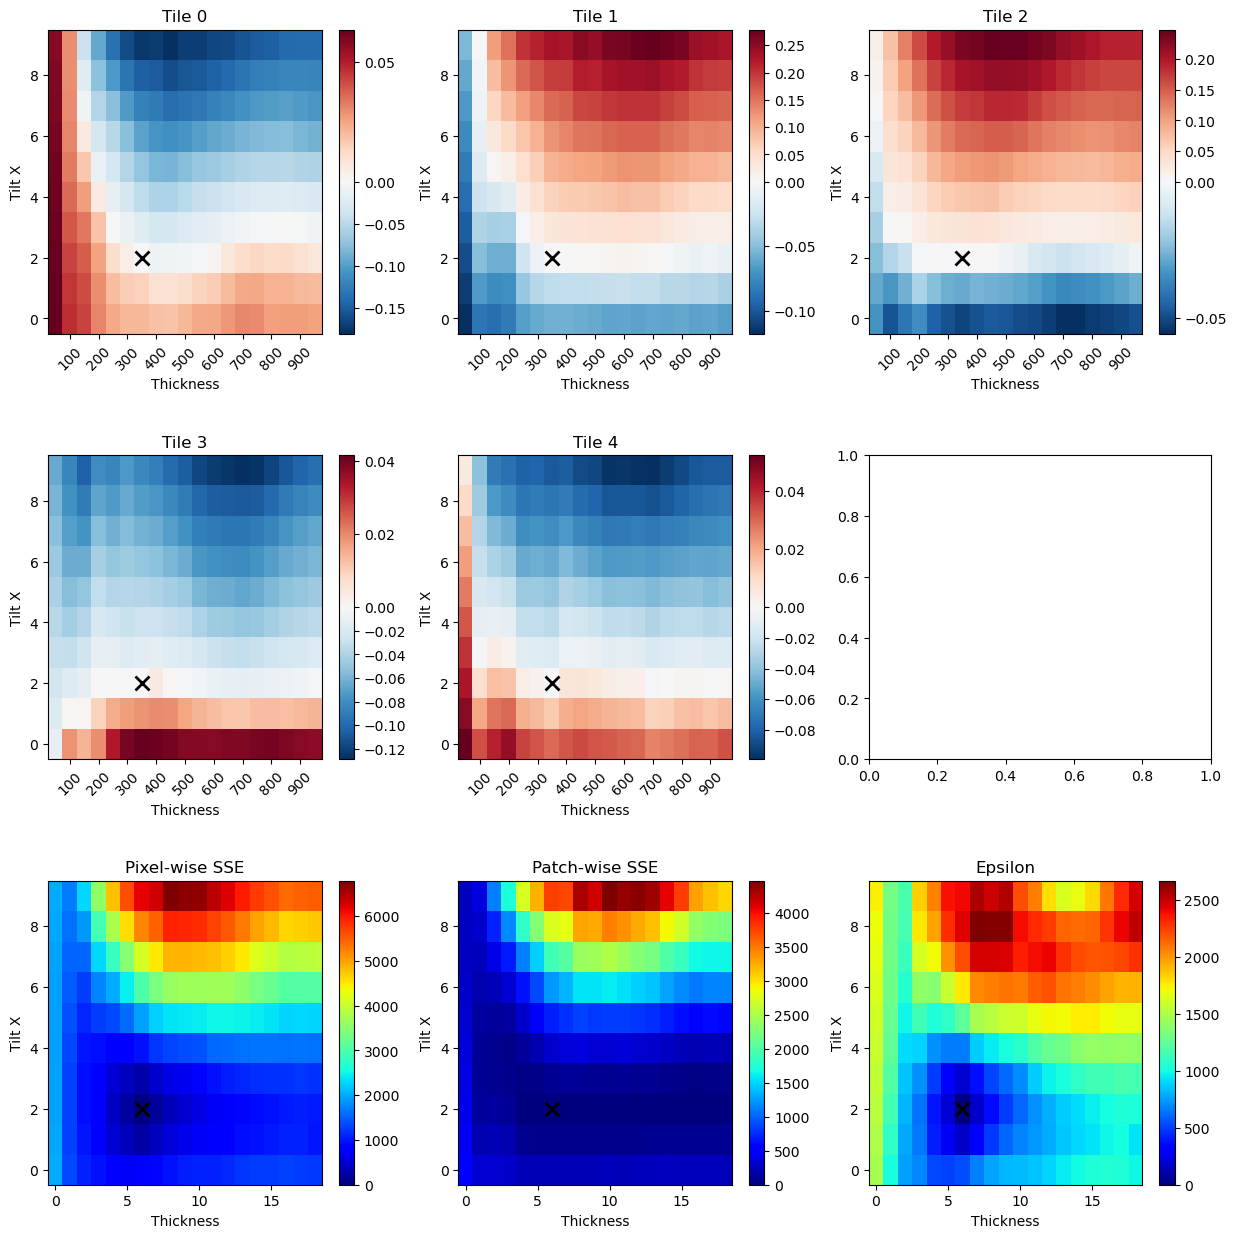

In [9]:
fig,ax = plt.subplots(3,3, figsize=(15,15))
fig.subplots_adjust(hspace=0.4)#, wspace=0.4)
for ind, axis in enumerate(ax.ravel()[:arr_tiles.shape[2]]):
    cnorm = TwoSlopeNorm(vcenter=0)
    im = axis.imshow( (arr_tiles[:,:,ind]-arr_tiles[ground_truth_x_ind[0],
                                                    ground_truth_x_ind[1],ind]).T, #make thickness on x axis
                    cmap='RdBu_r', aspect='auto', norm=cnorm,origin='lower')
    axis.plot(ground_truth_x_ind[0], ground_truth_x_ind[1], 'kx', markersize=10, markeredgewidth=2)
    axis.set_title(f'Tile {ind}')
    axis.set_xlabel('Thickness')
    axis.set_xticks(np.arange(arr_tiles.shape[0])[1::2], thickness_range[1::2], rotation=45) #from 1st tick, every 2nd
    # axis.set_xticks(np.arange(arr_tiles.shape[0]))
    # axis.set_xticklabels(thickness_range)
    axis.set_ylabel('Tilt X')
    #axis.set_yticks(ticks=np.arange(arr_tiles.shape[1]), labels=tilt_x_range)
    fig.colorbar(im, ax=axis)
    #else: axis.axis('off')

more_plots = [arr_pixel_sse, arr_patch_sse, arr_epsilon]
more_plots_titles = ['Pixel-wise SSE', 'Patch-wise SSE', 'Epsilon']
for ind, axis in enumerate(ax.ravel()[-len(more_plots):]):#[arr_tiles.shape[2]:arr_tiles.shape[2]+len(more_plots)]):
    im = axis.imshow(more_plots[ind].T,
                     origin='lower', cmap='jet', aspect='auto')
    axis.set_title(more_plots_titles[ind])
    axis.set_xlabel('Thickness');axis.set_ylabel('Tilt X')
    fig.colorbar(im, ax=axis)
    axis.plot(ground_truth_x_ind[0], ground_truth_x_ind[1], 'kx', markersize=10, markeredgewidth=2)

In [11]:
tiles = get_domain_tiles(torch.Tensor(load_pacbed(ground_truth_x)),0.31,reduce=False)

In [14]:
tiles.shape

torch.Size([1, 5, 157, 157])

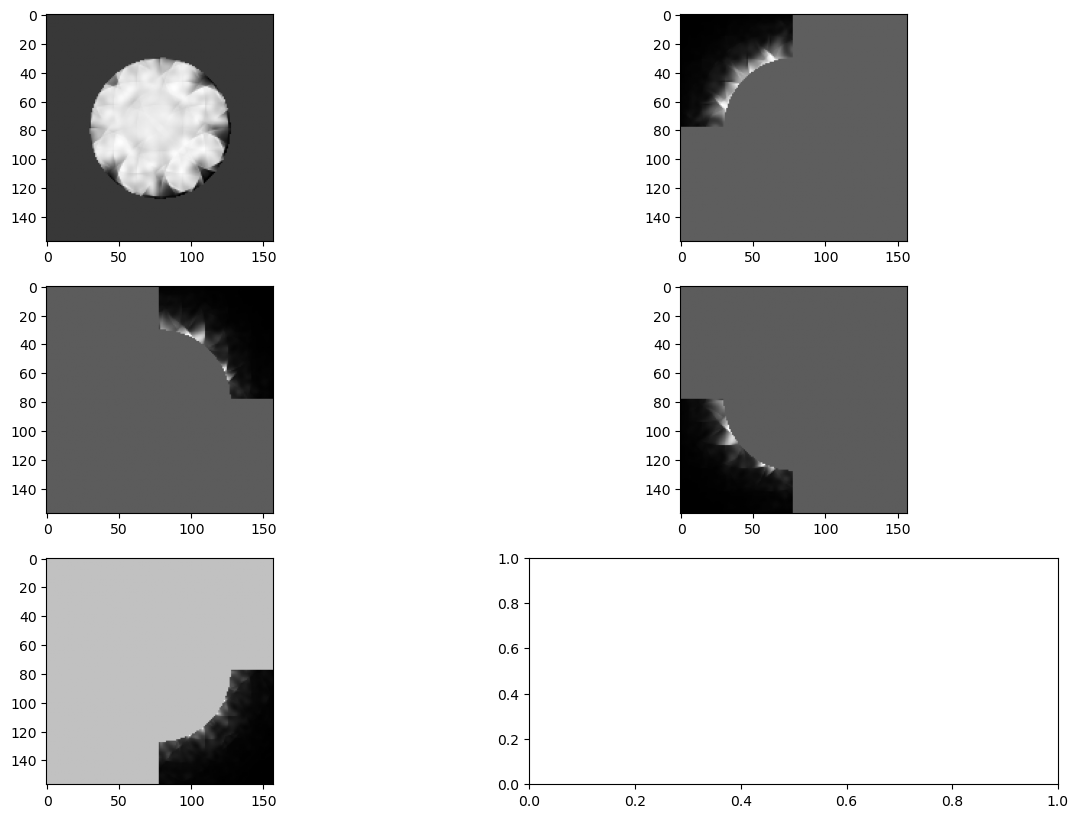

In [ ]:
fig,ax = plt.subplots(3,2,figsize=(15,10))
for i,axis in enumerate(ax.ravel()[:-1]):
    axis.imshow(tiles[0,i,:,:],cmap='gray')


In [11]:
from bott.utils import create_circular_mask, quadrant_masks_from_inv

In [6]:
mask = create_circular_mask(157,157, radius=0.31)
inv_mask = ~mask

In [10]:
mask.sum()

tensor(7440)

In [12]:
tiles = quadrant_masks_from_inv(inv_mask)

In [15]:
tiles[0].shape

torch.Size([157, 157])

In [17]:
tiles[1].sum()

tensor(4303)

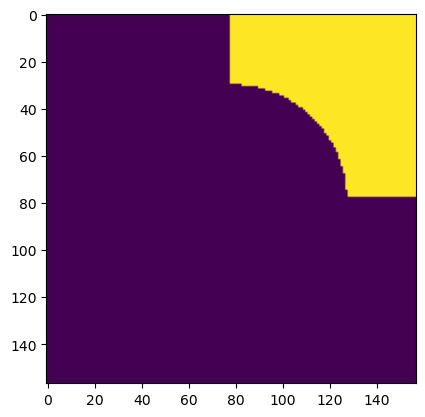

In [16]:
plt.imshow(tiles[1])

### archive

In [110]:
ground_truth.shape[0]//sq_tile_width

52

In [20]:
from bott.reduction import get_square_tiles

In [113]:
temp = get_square_tiles(ground_truth,num_tiles=sq_tile_width,
                        reduce=False)

In [120]:
tiles5 = get_square_tiles(ground_truth,num_tiles=5,
                        reduce=False)

In [21]:
tiles7 = get_square_tiles(ground_truth,num_tiles=7,
                        reduce=False)

In [116]:
temp[0].shape

torch.Size([52, 52])

In [117]:
len(temp)

9

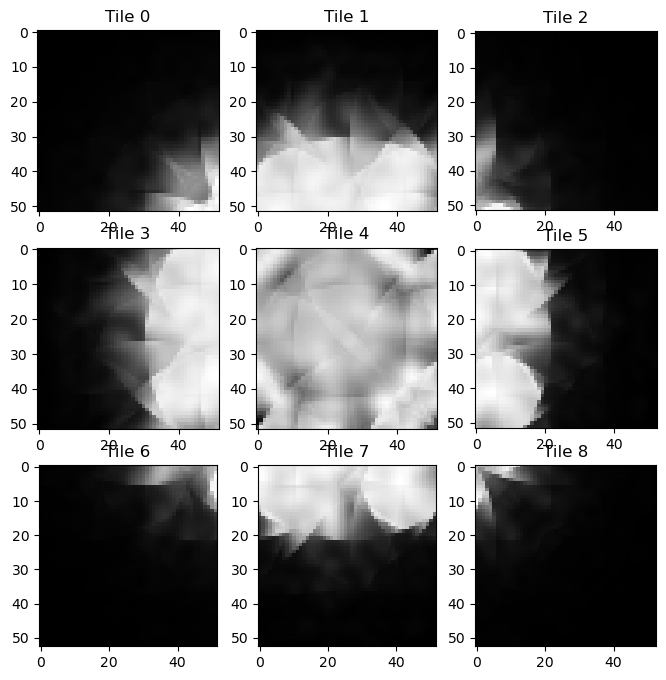

In [119]:
fig,ax = plt.subplots(sq_tile_width,sq_tile_width, figsize=(8,8))
for ind, axis in enumerate(ax.ravel()):
    axis.imshow(temp[ind], cmap='gray')
    axis.set_title(f'Tile {ind}')

In [25]:
4/9

0.4444444444444444

In [23]:
16/25

0.64

In [24]:
24/49

0.4897959183673469

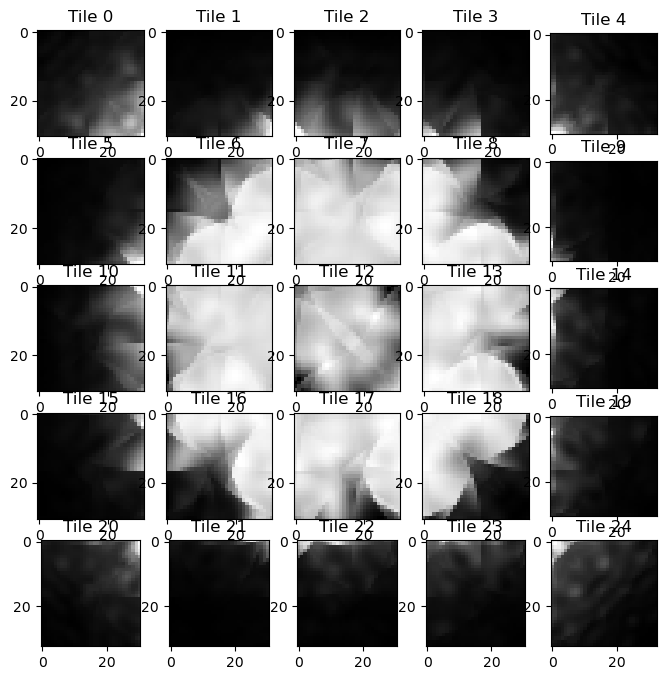

In [121]:
fig,ax = plt.subplots(5,5, figsize=(8,8))
for ind, axis in enumerate(ax.ravel()):
    axis.imshow(tiles5[ind], cmap='gray')
    axis.set_title(f'Tile {ind}')

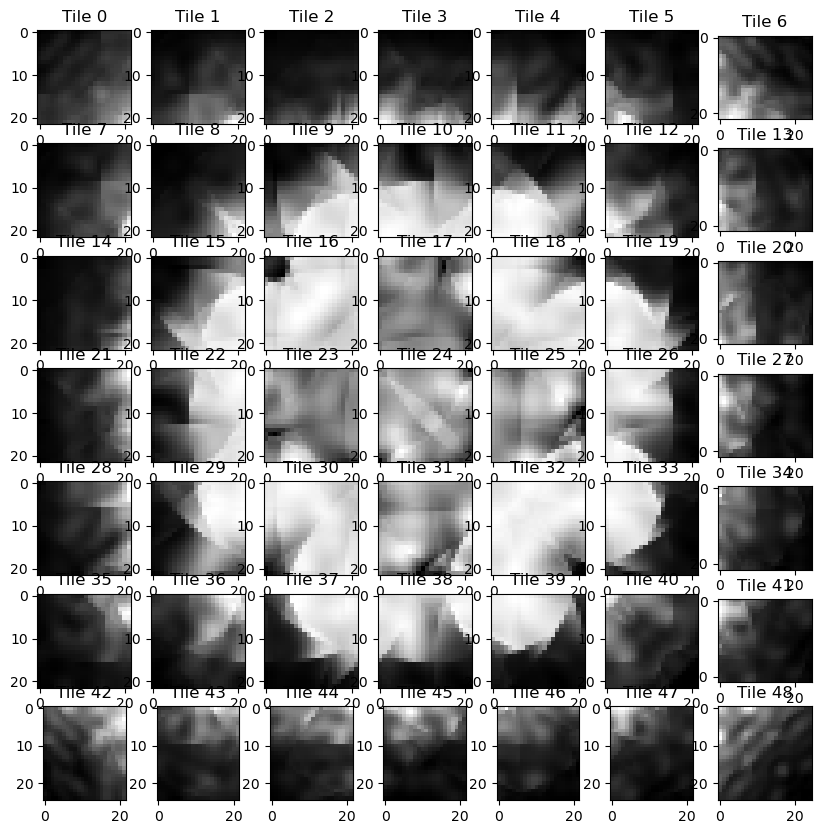

In [22]:
fig,ax = plt.subplots(7,7, figsize=(10,10))
for ind, axis in enumerate(ax.ravel()):
    axis.imshow(tiles7[ind], cmap='gray')
    axis.set_title(f'Tile {ind}')

In [123]:
import importlib

In [125]:
#importlib.reload(bott.utils)
from bott.utils import create_circular_mask

In [126]:
imgsize = ground_truth.shape
mask = create_circular_mask(imgsize[0], imgsize[1], radius=0.31)
inv_mask = ~mask

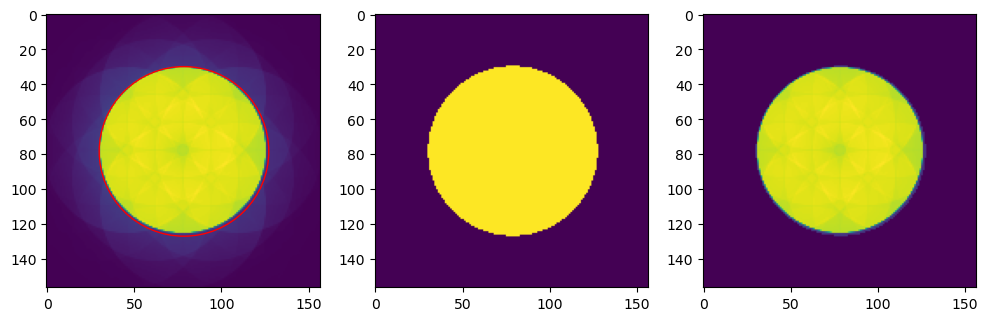

In [130]:
fig,ax = plt.subplots(1,3,figsize=(12,4))
ax[0].imshow(imgs[50][0])
circ = plt.Circle((157/2, 157/2), radius=0.31*157, color='r', fill=False)
ax[0].add_patch(circ)
ax[1].imshow(mask)
ax[2].imshow(torch.Tensor(imgs[50][0])*mask)

In [ ]:
mask